After completing this practical, the learner should be able to:

* implement common activation functions;
* implement their derivatives;
* compare function and derivative curves;
* identify saturation, vanishing gradients, and dead neurons;
* select suitable activations for hidden and output layers.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 1000)

print("Libraries imported successfully.")

c:\Users\shraw\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully.


### Common Plotting Function
The blue curve represents the original activation function.

The orange curve represents its derivative.

In [2]:
def plot_function_and_derivative(name, function, derivative, x_values=x):
    y = function(x_values)
    dy = derivative(x_values)

    plt.figure(figsize=(9, 5))
    plt.plot(x_values, y, label="Original function: f(z)", linewidth=2)
    plt.plot(x_values, dy, label="Derivative: f'(z)", linewidth=2)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel("Input z")
    plt.ylabel("Output")
    plt.title(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

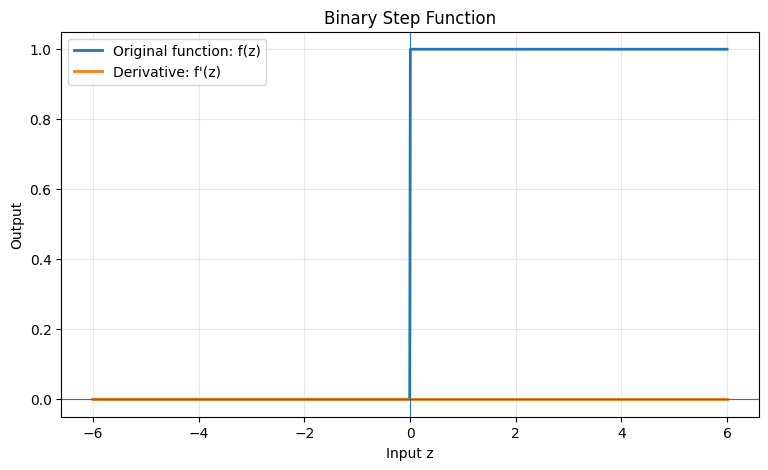

In [3]:
def binary_step(z):
    return np.where(z >= 0, 1.0, 0.0)

def binary_step_derivative(z):
    # Zero is used for visualization.
    # Mathematically, the derivative is undefined at z = 0.
    return np.zeros_like(z)

plot_function_and_derivative(
    "Binary Step Function",
    binary_step,
    binary_step_derivative
)

The output changes suddenly from 0 to 1.

### Original Function

$$
f(z)=z
$$

### Derivative

$$
\frac{df(z)}{dz}=1
$$

or equivalently,

$$
f'(z)=1
$$

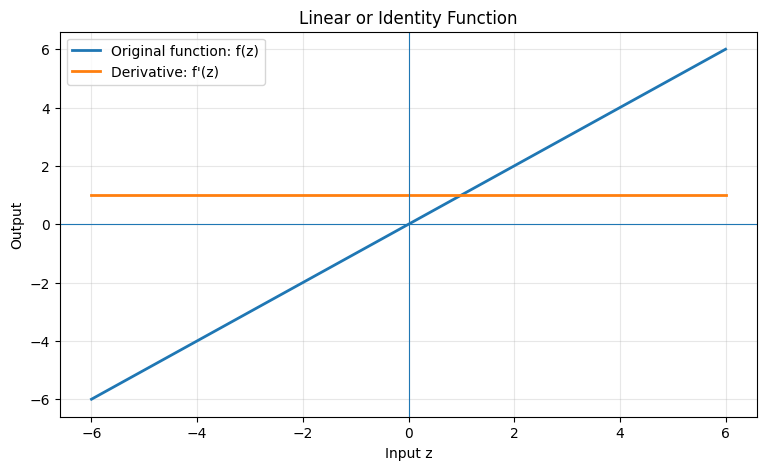

In [4]:
def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)

plot_function_and_derivative(
    "Linear or Identity Function",
    linear,
    linear_derivative
)

Observations

* The output is equal to the input.
* The derivative remains constant at 1.
* It does not introduce nonlinearity.
* It is commonly used in the output layer for regression.

### 3. Sigmoid Function

#### Original Function

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

#### Derivative

$$
\sigma'(z)=\sigma(z)\left(1-\sigma(z)\right)
$$

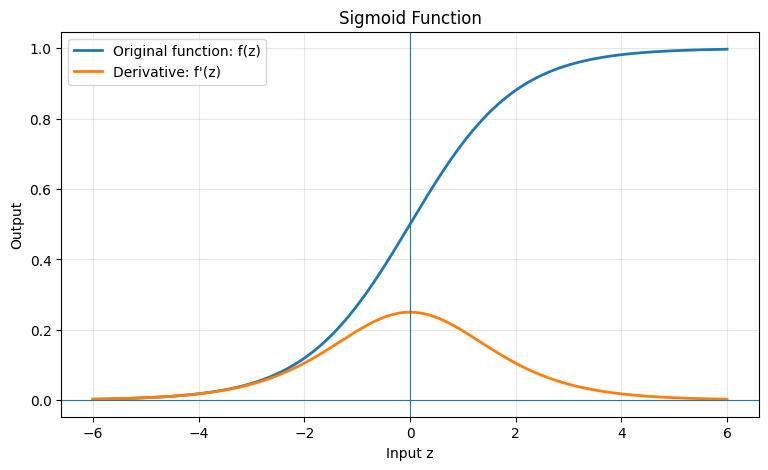

In [5]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

plot_function_and_derivative(
    "Sigmoid Function",
    sigmoid,
    sigmoid_derivative
)

Observations

* The output lies between 0 and 1.
* The derivative is maximum at z = 0.
* The derivative becomes very small for large positive or negative inputs.
* This creates the vanishing-gradient problem.
* Sigmoid is commonly used for binary-classification output.

### 4. Hyperbolic Tangent (tanh) Function

#### Original Function

$$
f(z)=\tanh(z)
$$

#### Equivalent Form

$$
f(z)=\frac{e^{z}-e^{-z}}{e^{z}+e^{-z}}
$$

#### Derivative

$$
f'(z)=1-\tanh^2(z)
$$

or equivalently,

$$
f'(z)=1-f^2(z)
$$

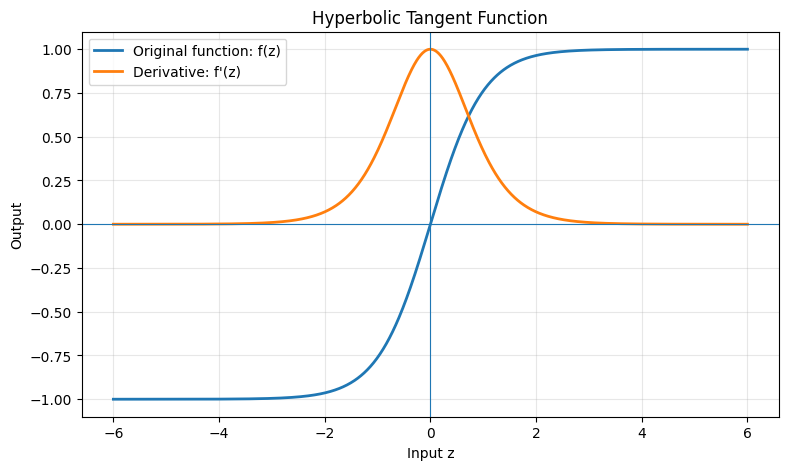

In [6]:
def tanh_function(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1.0 - np.tanh(z) ** 2

plot_function_and_derivative(
    "Hyperbolic Tangent Function",
    tanh_function,
    tanh_derivative
)

### Observations

* The output lies between -1 and 1.
* It is zero-centred.
* Its derivative is largest near z = 0.
* It saturates for large positive and negative irputs.
* It can still suffer from vanishing gradients.

### 5. ReLU (Rectified Linear Unit) Function

#### Original Function

$$
f(z)=\max(0,z)
$$

#### Equivalent Piecewise Form

$$
f(z)=
\begin{cases}
0, & z<0,\\
z, & z\geq0.
\end{cases}
$$

#### Derivative

$$
f'(z)=
\begin{cases}
0, & z<0,\\
1, & z>0.
\end{cases}
$$

**Note:** The derivative at \(z=0\) is **undefined**, but in practice it is **chosen by convention** (commonly taken as \(0\), \(1\), or any value in \([0,1]\), with most deep-learning libraries using \(0\)).

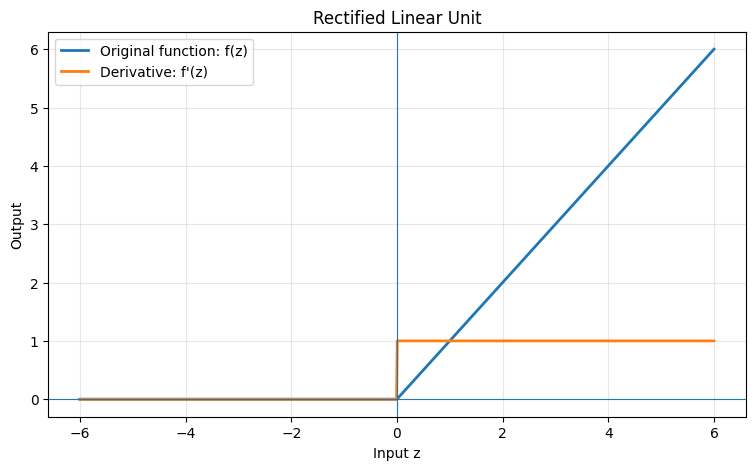

In [7]:
def relu(z):
    return np.maximum(0.0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)

plot_function_and_derivative(
    "Rectified Linear Unit",
    relu,
    relu_derivative
)

### Observations

* Negative inputs produce zero output.
* Positive inputs pass through unchanged.
* Positive-side gradients do not vanish.
* A neuron receiving only negative inputs may stop learning.
* This behaviour is called the dead-ReLU problem.

### 6. Leaky ReLU Function

Let $\alpha = 0.01$.

#### Original Function

$$
f(z)=
\begin{cases}
z, & z\geq0,\\
\alpha z, & z<0.
\end{cases}
$$

#### Derivative

$$
f'(z)=
\begin{cases}
1, & z>0,\\
\alpha, & z<0.
\end{cases}
$$

**Note:** Like ReLU, the derivative at \(z=0\) is **undefined**, but in practice it is chosen by convention.

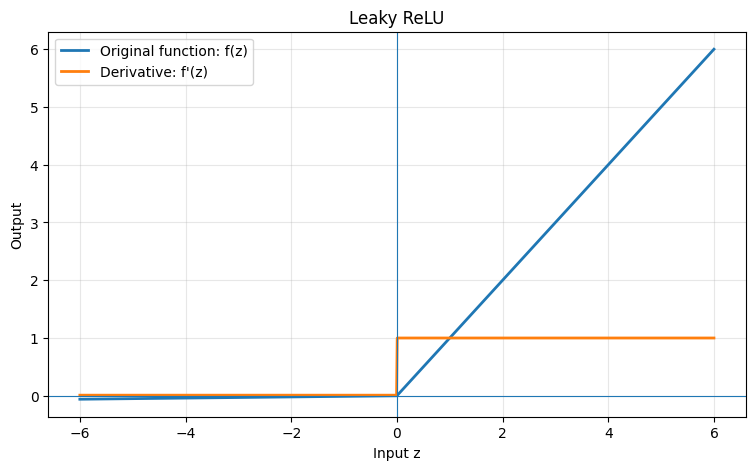

In [8]:
alpha = 0.01

def leaky_relu(z):
    return np.where(z >= 0, z, alpha * z)

def leaky_relu_derivative(z):
    return np.where(z > 0, 1.0, alpha)

plot_function_and_derivative(
    "Leaky ReLU",
    leaky_relu,
    leaky_relu_derivative
)

### Observations

* Negative inputs retain a small nonzero output.
* The derivative remains nonzero in the negative region.
* It reduces the dead-neuron problem.
* The negative slope o is fixed before training.

Alpha value is kept to be small.

### 7. ELU (Exponential Linear Unit) Function

Let $\alpha = 1$.

#### Original Function

$$
f(z)=
\begin{cases}
z, & z>0,\\
\alpha\left(e^{z}-1\right), & z\leq0.
\end{cases}
$$

#### Derivative

$$
f'(z)=
\begin{cases}
1, & z>0,\\
\alpha e^{z}, & z\leq0.
\end{cases}
$$

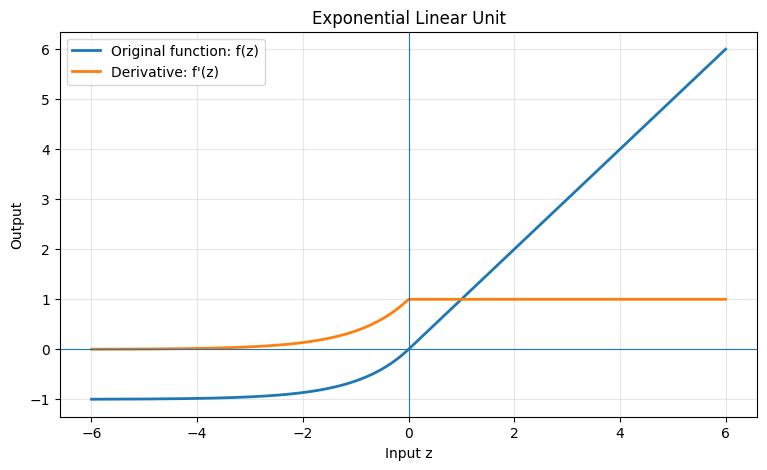

In [9]:
elu_alpha = 1.0

def elu(z):
    return np.where(z > 0, z, elu_alpha * (np.exp(z) - 1.0))

def elu_derivative(z):
    return np.where(z > 0, 1.0, elu_alpha * np.exp(z))

plot_function_and_derivative(
    "Exponential Linear Unit",
    elu,
    elu_derivative
)

### Observations

* Positive inputs behave like ReLU.
* Negative inputs produce smooth negative outputs.
* Negative outputs can move the activation mean closer to zero.
* ELU reduces dead neurons but is computationally costlier than ReLU.

### 8. Softplus Function

#### Original Function

$$
f(z)=\ln\left(1+e^{z}\right)
$$

#### Derivative

$$
f'(z)=\frac{1}{1+e^{-z}}
$$

or equivalently,

$$
f'(z)=\sigma(z)
$$

**Note:** The derivative of the **Softplus** function is the **Sigmoid** function.

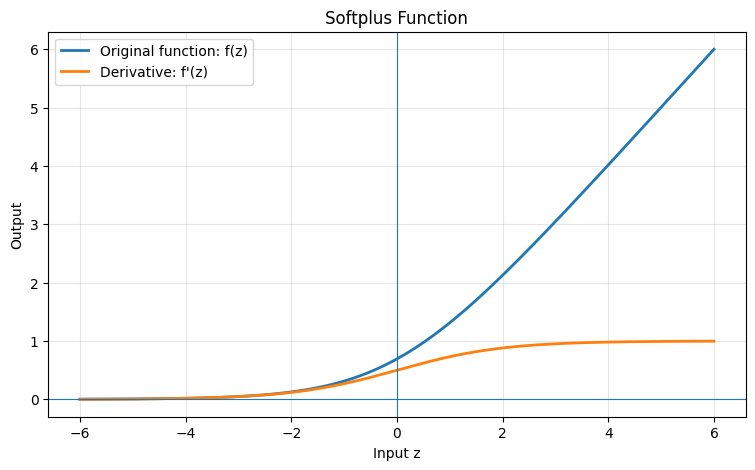

In [10]:
def softplus(z):
    return np.log(1 + np.exp(z))

def softplus_derivative(z):
    return sigmoid(z)

plot_function_and_derivative(
    "Softplus Function",
    softplus,
    softplus_derivative
)

### Observations

* Softplus is a smooth approximation to ReLU.
* It has no sharp corner at zero.
* Its derivative changes smoothly between 0 and 1.
* It does not produce exact zero outputs.

### 9. Swish (SiLU) Function

#### Original Function

$$
f(z)=z\,\sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

#### Derivative

$$
f'(z)=\sigma(z)+z\,\sigma(z)\left(1-\sigma(z)\right)
$$

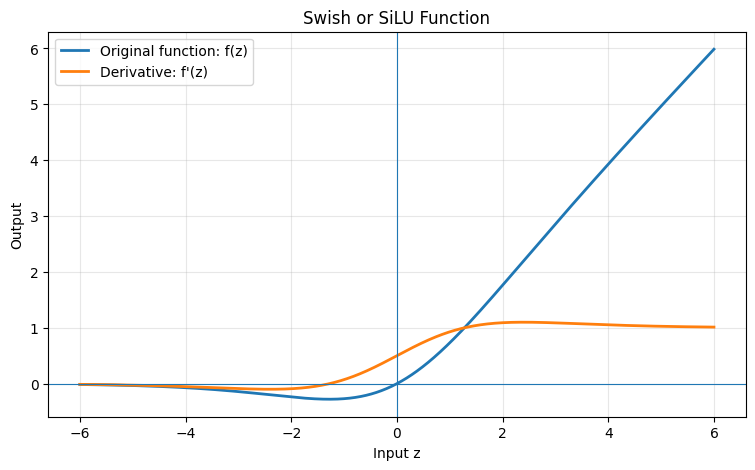

In [11]:
def swish(z):
    return z * sigmoid(z)

def swish_derivative(z):
    s = sigmoid(z)
    return s + z * s * (1.0 - s)

plot_function_and_derivative(
    "Swish or SiLU Function",
    swish,
    swish_derivative
)

### Observations

* Swish is smooth and differentiable.
* It allows small negative outpITts.
* It is slightly non-monotonic in the negative region.
* It is used in several modern deep-learning architectures.

### 10. GELU (Gaussian Error Linear Unit) Function

#### Original Function

$$
\text{GELU}(z)=z\,\Phi(z)
$$

where

- $\Phi(z)$ is the **standard normal cumulative distribution function (CDF)**.

#### Derivative

$$
\text{GELU}'(z)=\Phi(z)+z\,\phi(z)
$$

where

- $\phi(z)$ is the **standard normal probability density function (PDF)**.

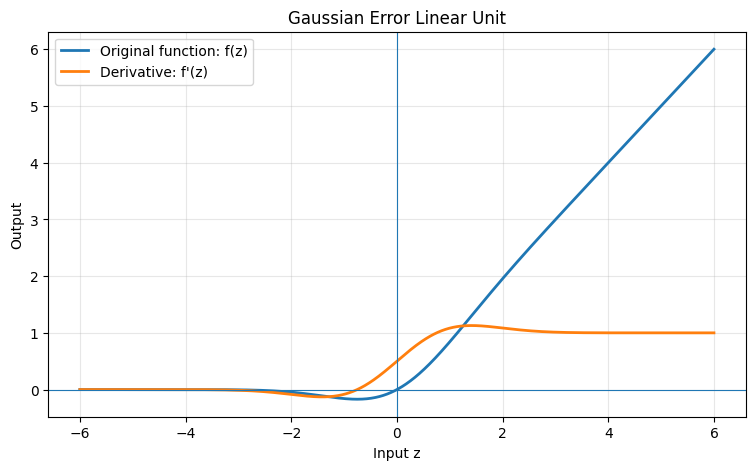

In [14]:
def normal_cdf(z):
    values = np.vectorize(math.erf)(z / np.sqrt(2.0))
    return 0.5 * (1.0 + values)

def normal_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)

def gelu(z):
    return z * normal_cdf(z)

def gelu_derivative(z):
    return normal_cdf(z) + z * normal_pdf(z)

plot_function_and_derivative(
    "Gaussian Error Linear Unit",
    gelu,
    gelu_derivative
)

### Observations

* GELU is smooth and slightly non-monotonic.
* It does not abruptly discard negative values.
* The derivative changes smoothly.
* GELU is widely used in Transformer-based models.

### 11. Softmax Function

Softmax operates on a vector of class scores.

#### Original Function

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_k e^{z_k}}
$$

#### Derivative

The derivative is a matrix called the **Jacobian**.

For the same output and input position:

$$
\frac{\partial s_i}{\partial z_i}=s_i(1-s_i)
$$

For different output and input positions:

$$
\frac{\partial s_i}{\partial z_j}=-s_i s_j,\qquad i\neq j
$$

In [12]:
import numpy as np

def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

def softmax_jacobian(logits):
    probabilities = softmax(logits)
    return np.diag(probabilities) - np.outer(probabilities, probabilities)

logits = np.array([2.0, 1.0, 0.1])
probabilities = softmax(logits)
jacobian = softmax_jacobian(logits)

print("Input logits:", logits)
print("Softmax probabilities:", probabilities)
print("Sum of probabilities:", probabilities.sum())
print("\nSoftmax derivative matrix:")
print(jacobian)

Input logits: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0

Softmax derivative matrix:
[[ 0.22471864 -0.1597636  -0.06495503]
 [-0.1597636   0.18365923 -0.02389562]
 [-0.06495503 -0.02389562  0.08885066]]


### Comparative Behaviour

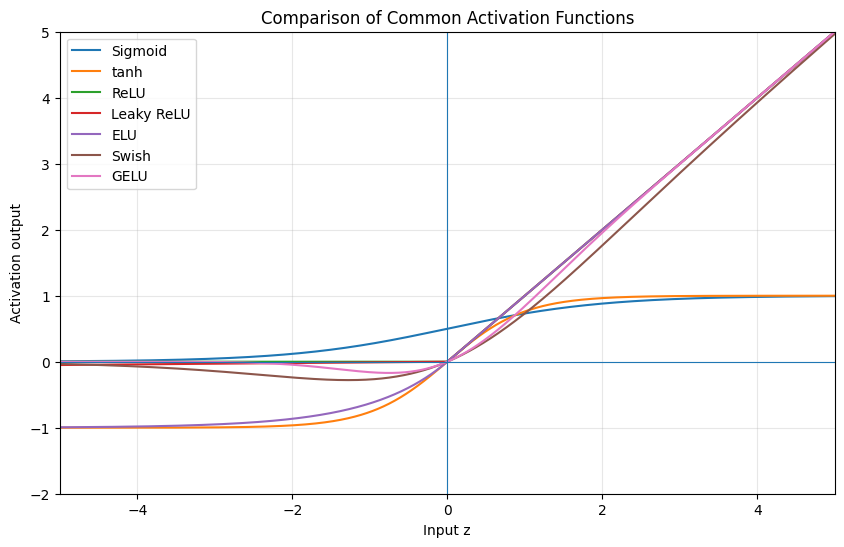

In [15]:
comparison_functions = {
    "Sigmoid": sigmoid,
    "tanh": tanh_function,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "ELU": elu,
    "Swish": swish,
    "GELU": gelu
}
plt.figure(figsize=(10, 6))

for name, function in comparison_functions.items():
    plt.plot(x, function(x), label=name)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlim(-5, 5)
plt.ylim(-2, 5)
plt.xlabel("Input z")
plt.ylabel("Activation output")
plt.title("Comparison of Common Activation Functions")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Final Observations

1. The activation function determines both neuron output and gradient behaviour.
2. Sigmoid and tanh saturate for large input magnitudes.
3. ReLU is simple and efficient but can create dead neurons.
4. Leaky ReLU keeps a small gradient for negative inputs.
5. ELU provides smooth negative outputs.
6. Softplus is a smooth alternative to ReLU.
7. Swish and GELU provide smooth gradient flow and allow small negative outputs.
8. Softmax must be treated as a vector function.
9. Hidden-layer and output-layer activations serve different purposes.
10. No single activation function is best for every neural-network architecture.

# Recommendations

- Use **ReLU** as a simple starting choice for many hidden layers.
- Use **Leaky ReLU** when dead ReLU neurons are observed.
- Use **ELU** when faster convergence and smoother negative activations are desired.
- Use **Softplus** when a smooth approximation of ReLU is preferred.
- Use **Swish** for deep neural networks where improved gradient flow is beneficial.
- Use **GELU** in Transformer-based models such as **BERT**, **GPT**, and **Vision Transformers (ViT)**.
- Use **Sigmoid** for binary-classification output layers.
- Use **Tanh** when zero-centered outputs are preferred in hidden layers.
- Use **Softmax** for single-label multiclass classification output.
- Use **Linear** for unrestricted regression output.
- Compare activation functions experimentally using the same model, dataset, and training conditions, as the optimal choice depends on the task and network architecture.